# Level 1 - Data Cleaning and Exploratory Data Analysis

## Internship Project - Codveda Technologies

### Objective
The objective of this project is to clean and preprocess the dataset, perform exploratory data analysis (EDA), and visualize patterns and relationships within the data using Python libraries such as pandas, matplotlib, and seaborn.

## Step 1: Importing Required Libraries

In this step, I imported the required Python libraries for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")


Libraries imported successfully


## Step 2: Loading the Dataset

The dataset is loaded using pandas. The first five rows are displayed to understand the structure of the data.

In [7]:
df = pd.read_csv('/1) iris.csv')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3: Understanding the Dataset

This step shows the number of rows and columns, column names, data types, and general information about the dataset.

In [8]:
df.shape

(150, 5)

In [9]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [10]:
df.info

<bound method DataFrame.info of      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]>

## Step 4: Checking Missing Values

Missing values can affect the quality of analysis. In this step, I checked whether the dataset contains any missing values.

In [11]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


## Step 5: Checking and Removing Duplicate Rows

Duplicate rows can affect the accuracy of the analysis. In this step, duplicate records are identified and removed.

In [12]:
df.duplicated().sum()

np.int64(3)

In [13]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Step 6: Handling Missing Values

If missing values are present, numerical columns are filled with the median value, while categorical columns are filled with the mode value.

In [16]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna(df[col].mode()[0])
  else:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()


/tmp/ipykernel_10226/3435979040.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())
/tmp/ipykernel_10226/3435979040.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


## Step 7: Saving the Cleaned Dataset

After cleaning the data, the cleaned dataset is saved as a new CSV file.

In [17]:
df.to_csv('iris_cleaned.csv', index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


# Task 2: Exploratory Data Analysis

## Step 8: Summary Statistics

Summary statistics help understand the central tendency, spread, and distribution of numerical features.

In [18]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [20]:
df.mean(numeric_only=True)

,0
sepal_length,5.856463
sepal_width,3.055782
petal_length,3.780272
petal_width,1.208844


In [19]:
df.median(numeric_only=True)

,0
sepal_length,5.8
sepal_width,3.0
petal_length,4.4
petal_width,1.3


In [21]:
df.mode()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.0,3.0,1.4,0.2,versicolor
1,NaN,NaN,1.5,NaN,NaN


In [22]:
df.std(numeric_only=True)

,0
sepal_length,0.829100
sepal_width,0.437009
petal_length,1.759111
petal_width,0.757874


## Step 9: Histograms

Histograms are used to visualize the distribution of numerical features in the dataset.

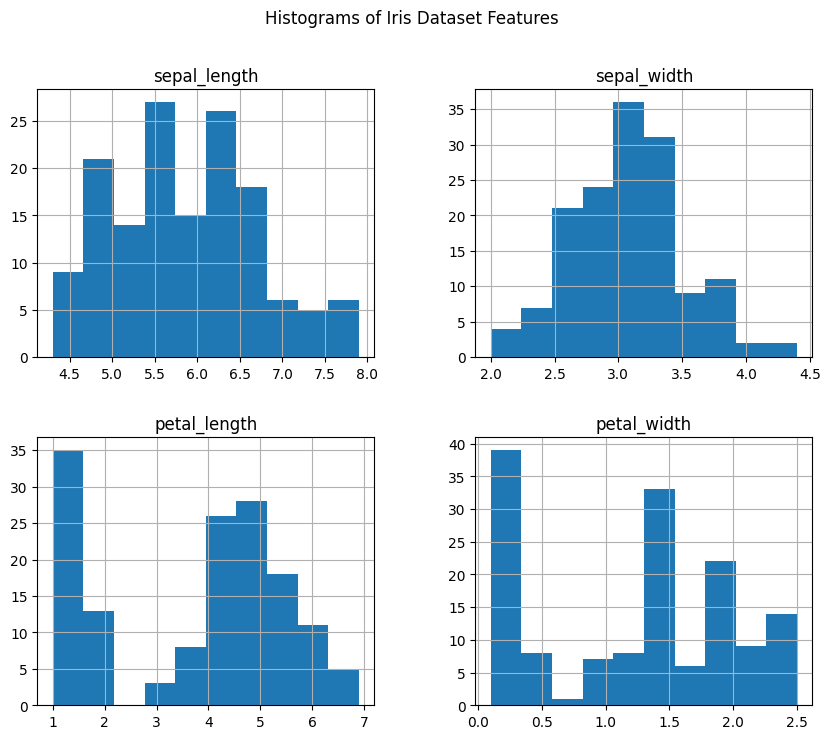

In [26]:
df.hist(figsize=(10, 8))
plt.suptitle("Histograms of Iris Dataset Features")
plt.show()

## Step 10: Boxplots

Boxplots help detect the spread of data and possible outliers in numerical features.

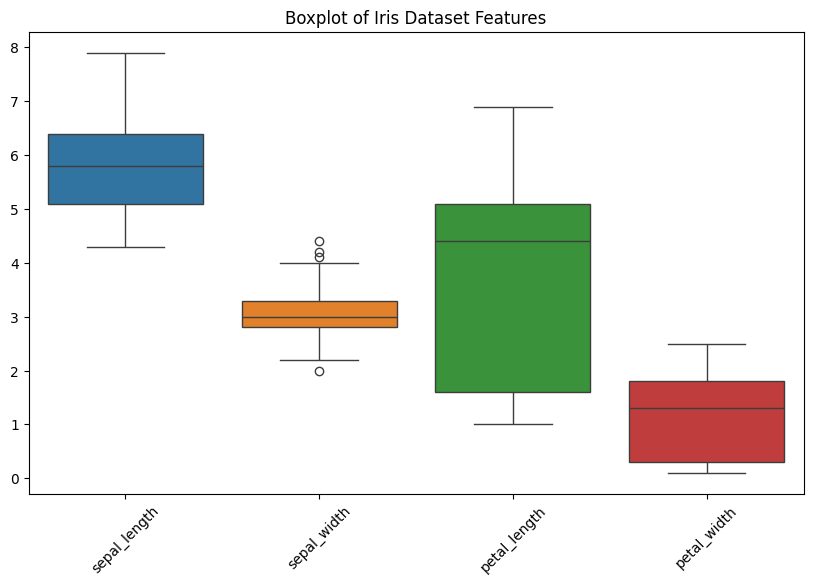

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title("Boxplot of Iris Dataset Features")
plt.xticks(rotation=45)
plt.show()

## Step 11: Correlation Heatmap

A correlation heatmap shows the relationship between numerical variables in the dataset.

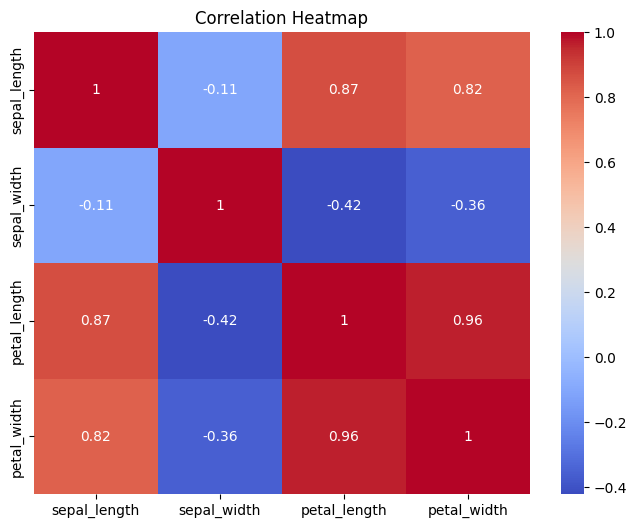

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Step 12: Scatter Plot

A scatter plot is used to visualize the relationship between two numerical features.

In [29]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

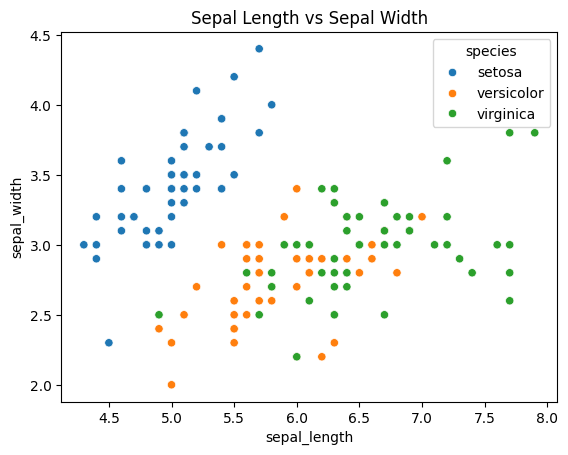

In [30]:
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue=df.columns[-1]
)

plt.title("Sepal Length vs Sepal Width")
plt.show()

# Conclusion

In this Level 1 project, I completed data cleaning and exploratory data analysis on the Iris dataset.

First, I loaded the dataset and checked its structure, missing values, duplicate rows, and data types. Duplicate records were removed, and missing values were handled if present.

After cleaning the dataset, I performed exploratory data analysis by calculating summary statistics such as mean, median, mode, and standard deviation. I also created visualizations including histograms, boxplots, scatter plots, and a correlation heatmap.

Overall, this analysis helped identify patterns, distributions, and relationships between numerical features in the dataset.